In [4]:
import pandas as pd

df = pd.read_csv("/content/Treasury_dataset.csv")

print(df.sample(10))
print(df.info())
print(df.describe())

          Date    Cash_Inflow  Cash_Outflow Currency_Rate Region        Notes
43  2023-02-13          66434           NaN         85.18    NaN   Data issue
27  2023-01-28          74198           NaN           NaN    NaN          NaN
87  2023-03-29  not_available       50118.0         84.49  India  High inflow
60  2023-03-02            NaN       45672.0           NaN  India       Normal
47  2023-02-17  not_available           NaN           NaN  India       Normal
19  2023-01-20          58148           NaN         83.28  India  High inflow
98  2023-04-09          80790           NaN           NaN    NaN   Data issue
94  2023-04-05            NaN       61597.0           NaN    NaN       Normal
68  2023-03-10  not_available           NaN         83.52    NaN  High inflow
24  2023-01-25  not_available       51185.0         83.06    NaN       Normal
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dty

In [5]:
df.isnull().sum()

,0
Date,0
Cash_Inflow,25
Cash_Outflow,60
Currency_Rate,33
Region,75
Notes,22


In [6]:
df.shape

(100, 6)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           100 non-null    object 
 1   Cash_Inflow    75 non-null     object 
 2   Cash_Outflow   40 non-null     float64
 3   Currency_Rate  67 non-null     object 
 4   Region         25 non-null     object 
 5   Notes          78 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


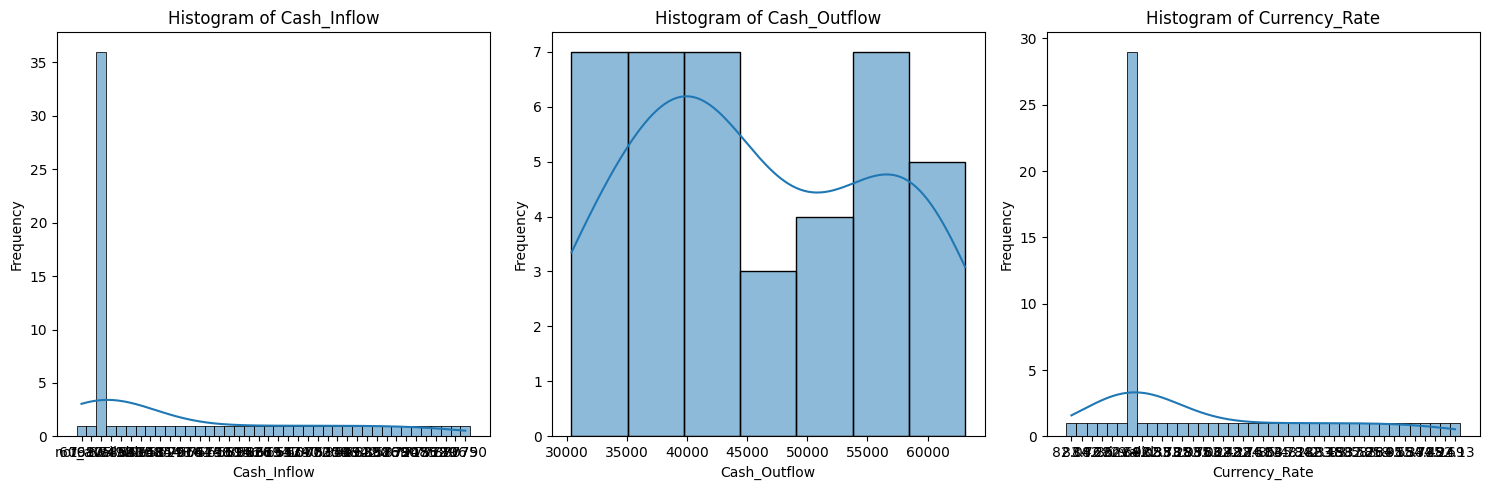

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for histograms
numerical_cols = ['Cash_Inflow', 'Cash_Outflow', 'Currency_Rate']

# Create subplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
df["Cash_Inflow"] = pd.to_numeric(df["Cash_Inflow"], errors='coerce')
df["Cash_Outflow"] = pd.to_numeric(df["Cash_Outflow"], errors='coerce')
df["Currency_Rate"] = pd.to_numeric(df["Currency_Rate"], errors='coerce')

In [10]:
df['Cash_Inflow'].fillna(df['Cash_Inflow'].median())
df['Cash_Outflow'].fillna(df['Cash_Outflow'].median())
df['Currency_Rate'].fillna(df['Currency_Rate'].median())

,Currency_Rate
0,83.78
1,83.78
2,82.04
3,83.78
4,83.76
...,...
95,85.69
96,83.78
97,82.13
98,83.78


In [11]:
df["Region"].fillna("Unknown", inplace=True)

/tmp/ipykernel_16746/1320690269.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Region"].fillna("Unknown", inplace=True)


In [12]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_16746/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [13]:
import numpy as np

df["Currency_Rate"] = pd.to_numeric(
    df["Currency_Rate"].replace(["NaN", "invalid"], np.nan),
    errors='coerce'
)

df["Currency_Rate"].fillna(method='ffill', inplace=True)
df["Currency_Rate"].fillna(method='bfill', inplace=True)

/tmp/ipykernel_16746/3670470444.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Currency_Rate"].fillna(method='ffill', inplace=True)
/tmp/ipykernel_16746/3670470444.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Currency_Rate"].fillna(method='ffill', inplace=True)
/tmp/ipykernel_16746/3670470444.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace m

In [14]:
df.isnull().sum()

,0
Date,0
Cash_Inflow,0
Cash_Outflow,0
Currency_Rate,0
Region,0
Notes,0


In [15]:
df["Date"] = pd.to_datetime(df["Date"])
#Feature Engineering
df["Net_Cash"] = df["Cash_Inflow"] - df["Cash_Outflow"]
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [16]:
df.sample(10)

,Date,Cash_Inflow,Cash_Outflow,Currency_Rate,Region,Notes,Net_Cash,Month,Day
46,2023-02-16,66772.0,35756.0,85.18,India,Normal,31016.0,2,16
91,2023-04-02,73189.0,50118.0,84.24,India,Missing region,23071.0,4,2
31,2023-02-01,61694.0,37751.0,82.76,India,Normal,23943.0,2,1
45,2023-02-15,66772.0,39321.0,85.18,Unknown,High inflow,27451.0,2,15
92,2023-04-03,73189.0,43429.0,84.24,Unknown,Missing region,29760.0,4,3
26,2023-01-27,56644.0,51185.0,83.43,Unknown,Data issue,5459.0,1,27
48,2023-02-18,66772.0,35756.0,82.20,Unknown,Normal,31016.0,2,18
3,2023-01-04,79805.0,30377.0,82.04,Unknown,Data issue,49428.0,1,4
32,2023-02-02,55156.0,58263.0,82.51,Unknown,Normal,-3107.0,2,2
9,2023-01-10,89330.0,41179.0,85.90,Unknown,High inflow,48151.0,1,10


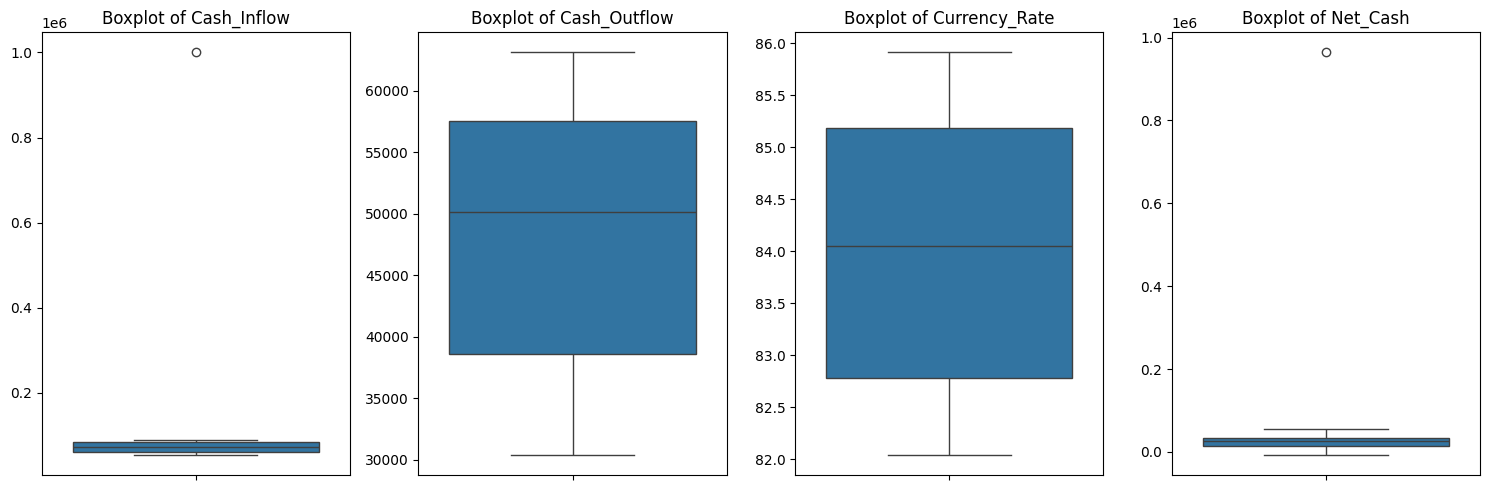

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleced numerical columns for boxplots
numerical_cols = ['Cash_Inflow', 'Cash_Outflow', 'Currency_Rate', 'Net_Cash']

#subplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('') # Remove y-label for cleaner look, title is sufficient

plt.tight_layout()
plt.show()

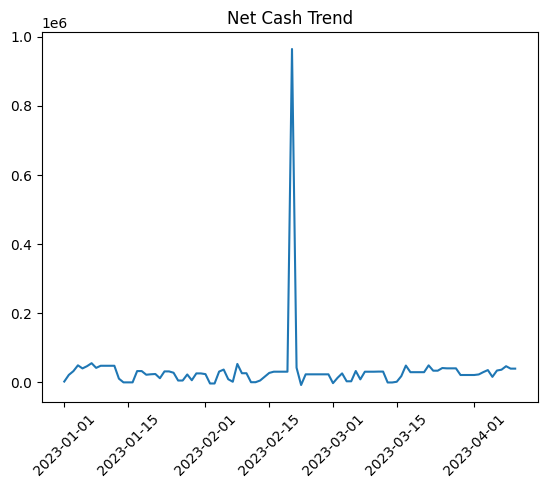

In [18]:
plt.plot(df["Date"], df["Net_Cash"])
plt.xticks(rotation=45)
plt.title("Net Cash Trend")
plt.show()

In [19]:
X = df[["Cash_Inflow", "Cash_Outflow", "Currency_Rate", "Month", "Day"]]
y = df["Net_Cash"]

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 2414.9594999999995
R2: 0.9426591187201906


In [ ]:
df.to_csv("cleaned_cashflow.csv", index=False)

In [23]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [24]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle

st.set_page_config(page_title="Treasury Dashboard", layout="wide")

st.title("💰 Treasury Cash Flow Dashboard")

# ------------------ LOAD DATA ------------------
df = pd.read_csv("cleaned_cashflow.csv")

# Convert Date if exists
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Day"] = df["Date"].dt.day
    df["Month"] = df["Date"].dt.month

# Load model
model = pickle.load(open("model.pkl", "rb"))

# ------------------ SIDEBAR ------------------
st.sidebar.title("Navigation")
option = st.sidebar.selectbox("Choose Option", ["Dashboard", "Prediction"])

# ================== DASHBOARD ==================
if option == "Dashboard":

    st.subheader("📊 Data Preview")
    st.dataframe(df.head())

    # Prediction on full dataset
    features = ["Cash_Inflow", "Cash_Outflow", "Currency_Rate", "Month", "Day"]
    X = df[features]
    df["Predicted_Cash"] = model.predict(X)

    # ✅ Download Report
    csv = df.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="📥 Download Report",
        data=csv,
        file_name="treasury_cashflow_report.csv",
        mime="text/csv"
    )

    # Charts
    if "Date" in df.columns:
        df_chart = df.set_index("Date")
    else:
        df_chart = df

    st.subheader("📈 Net Cash Trend")
    st.line_chart(df_chart["Net_Cash"])

    st.subheader("🔮 Predicted Cash Flow")
    st.line_chart(df_chart["Predicted_Cash"])

    # KPI Section
    st.subheader("📌 Key Metrics")
    col1, col2, col3 = st.columns(3)

    col1.metric("Average Cash", f"{df['Net_Cash'].mean():,.2f}")
    col2.metric("Max Cash", f"{df['Net_Cash'].max():,.2f}")
    col3.metric("Min Cash", f"{df['Net_Cash'].min():,.2f}")


# ================== PREDICTION ==================
elif option == "Prediction":

    st.subheader("🔮 Cash Flow Prediction")
    st.info("Enter values in the sidebar to predict cash flow")

    # -------- DEFAULT VALUES --------
    default_inflow = 200000.0
    default_outflow = 1670.0
    default_rate = 65.0

    # -------- RESET FUNCTION --------
    def reset_inputs():
        st.session_state["inflow"] = default_inflow
        st.session_state["outflow"] = default_outflow
        st.session_state["rate"] = default_rate
        st.session_state["date"] = pd.to_datetime("today")

    # -------- INITIALIZE SESSION --------
    if "inflow" not in st.session_state:
        reset_inputs()

    # Sidebar Inputs
    st.sidebar.header("Input Data")

    inflow = st.sidebar.number_input("Cash Inflow", key="inflow")
    outflow = st.sidebar.number_input("Cash Outflow", key="outflow")
    rate = st.sidebar.number_input("Currency Rate", key="rate")
    date = st.sidebar.date_input("Select Date", key="date")

    # Extract features
    day = date.day
    month = date.month

    # Buttons side by side
    col1, col2 = st.sidebar.columns(2)

    # Predict
    if col1.button("Predict"):
        pred = model.predict([[inflow, outflow, rate, month, day]])
        st.success(f"💰 Predicted Cash Flow: {pred[0]:,.2f}")

    # ✅ Clear Button (FIXED)
    col2.button("Clear", on_click=reset_inputs)

Writing app.py


In [25]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 121.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 103.2 kB/s eta 0:00:00


In [29]:
!ngrok config add-authtoken 3BpwIIqnpC4ykmSDBuh6ONTNnLO_2Fixb3SQY2XsgGJTooemE

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [30]:
!streamlit run app.py &>/content/logs.txt &

In [31]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unredemptive-felicitas-chunky.ngrok-free.dev" -> "http://localhost:8501"


In [28]:
#use to kill earlier sessions
!pkill -f streamlit
!pkill -f ngrok

In [ ]:
from google.colab import files
files.download("app.py")
files.download("model.pkl")
files.download("cleaned_cashflow.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>